<a href="https://colab.research.google.com/github/Yashi027/Sales_Forcasting/blob/main/SalesForcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

import os
os.makedirs('charts', exist_ok=True)

In [3]:
# loading the dataset
df = pd.read_csv('/content/sample_data/train.csv', encoding='latin1')

print("Shape:", df.shape)
df.head()

Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Parse Order Date and Ship Date as proper datetime objects (DD/MM/YYYY format)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'], dayfirst=True)

print("Order Date range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Ship Date range: ", df['Ship Date'].min(), "to", df['Ship Date'].max())
df[['Order Date', 'Ship Date']].dtypes

Order Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00
Ship Date range:  2015-01-07 00:00:00 to 2019-01-05 00:00:00


,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [8]:
df['Order Year']      = df['Order Date'].dt.year
df['Order Month']     = df['Order Date'].dt.month
df['Order Week']      = df['Order Date'].dt.isocalendar().week.astype(int)
df['Order DayOfWeek'] = df['Order Date'].dt.day_name()
df['Order Quarter']   = df['Order Date'].dt.quarter

def get_season(month: int) -> str:
    if month in (12, 1, 2):
        return 'Winter'
    elif month in (3, 4, 5):
        return 'Spring'
    elif month in (6, 7, 8):
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Order Month'].apply(get_season)
df['Fulfillment Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date', 'Order Year', 'Order Month', 'Order Week',
    'Order DayOfWeek', 'Order Quarter', 'Season', 'Fulfillment Days']].head()

,Order Date,Order Year,Order Month,Order Week,Order DayOfWeek,Order Quarter,Season,Fulfillment Days
0,2017-11-08,2017,11,45,Wednesday,4,Fall,3
1,2017-11-08,2017,11,45,Wednesday,4,Fall,3
2,2017-06-12,2017,6,24,Monday,2,Summer,4
3,2016-10-11,2016,10,41,Tuesday,4,Fall,7
4,2016-10-11,2016,10,41,Tuesday,4,Fall,7


In [9]:
print("Missing values per column")
print(df.isna().sum()[df.isna().sum() > 0])
print()
print("Duplicate rows")
print("Fully duplicated rows:", df.duplicated().sum())
print()
print("Data types")
print(df.dtypes)

Missing values per column
Postal Code    11
dtype: int64

Duplicate rows
Fully duplicated rows: 0

Data types
Row ID                       int64
Order ID                    object
Order Date          datetime64[ns]
Ship Date           datetime64[ns]
Ship Mode                   object
Customer ID                 object
Customer Name               object
Segment                     object
Country                     object
City                        object
State                       object
Postal Code                float64
Region                      object
Product ID                  object
Category                    object
Sub-Category                object
Product Name                object
Sales                      float64
Order Year                   int32
Order Month                  int32
Order Week                   int64
Order DayOfWeek             object
Order Quarter                int32
Season                      object
Fulfillment Days             int64
dtype: object


In [10]:
# Daily sales
daily_sales = (
    df.groupby('Order Date')['Sales'].sum()
    .asfreq('D', fill_value=0)
    .rename('Sales')
    .to_frame()
)

# Weekly sales
weekly_sales = daily_sales.resample('W')['Sales'].sum().to_frame()

# Monthly sales
monthly_sales = daily_sales.resample('ME')['Sales'].sum().to_frame()

print("Daily series length:  ", len(daily_sales))
print("Weekly series length: ", len(weekly_sales))
print("Monthly series length:", len(monthly_sales))

monthly_sales.head(12)

Daily series length:   1458
Weekly series length:  209
Monthly series length: 48


,Sales
Order Date,
2015-01-31,14205.7070
2015-02-28,4519.8920
2015-03-31,55205.7970
2015-04-30,27906.8550
2015-05-31,23644.3030
2015-06-30,34322.9356
2015-07-31,33781.5430
2015-08-31,27117.5365
2015-09-30,81623.5268


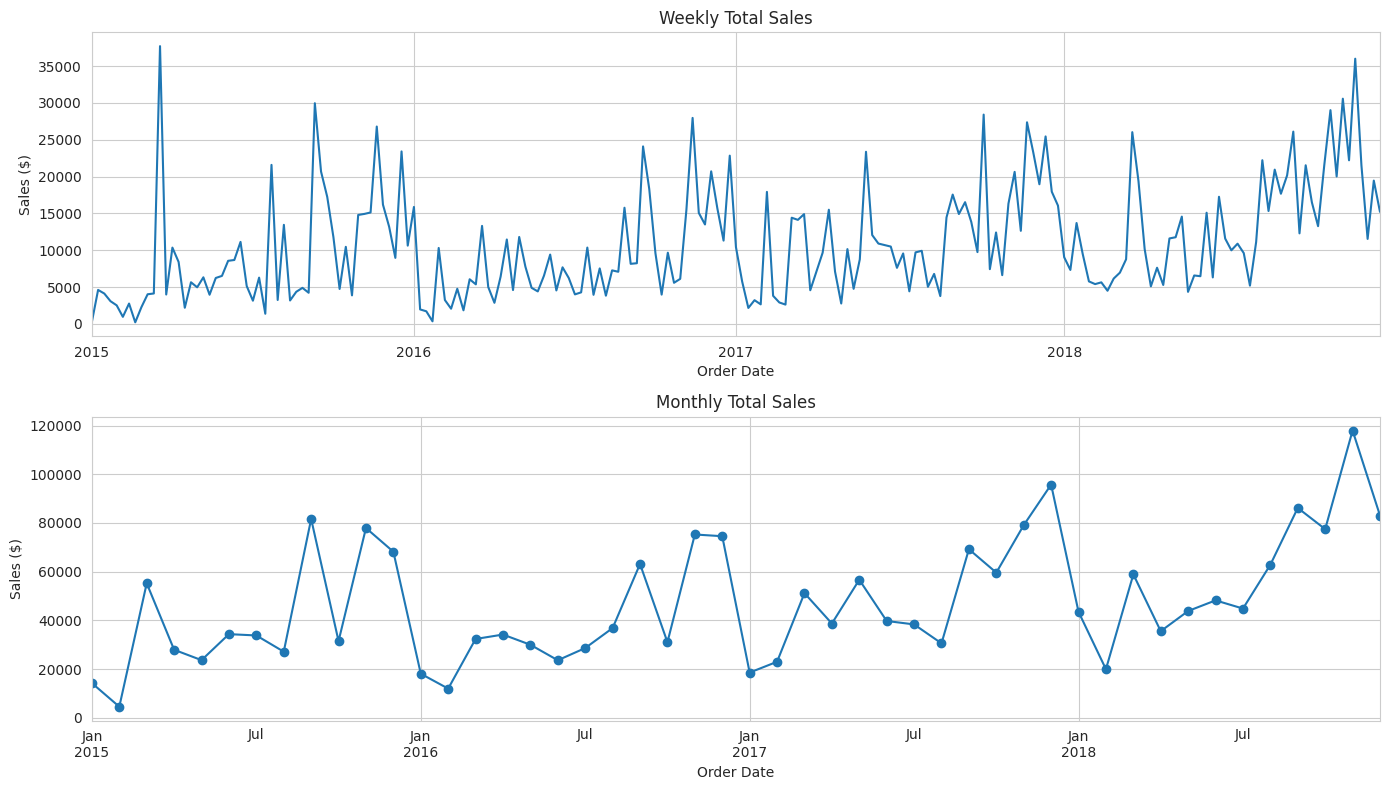

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
weekly_sales['Sales'].plot(ax=axes[0], title='Weekly Total Sales')
axes[0].set_ylabel('Sales ($)')
monthly_sales['Sales'].plot(ax=axes[1], title='Monthly Total Sales', marker='o')
axes[1].set_ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/task1_weekly_monthly_sales.png', dpi=120)
plt.show()

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


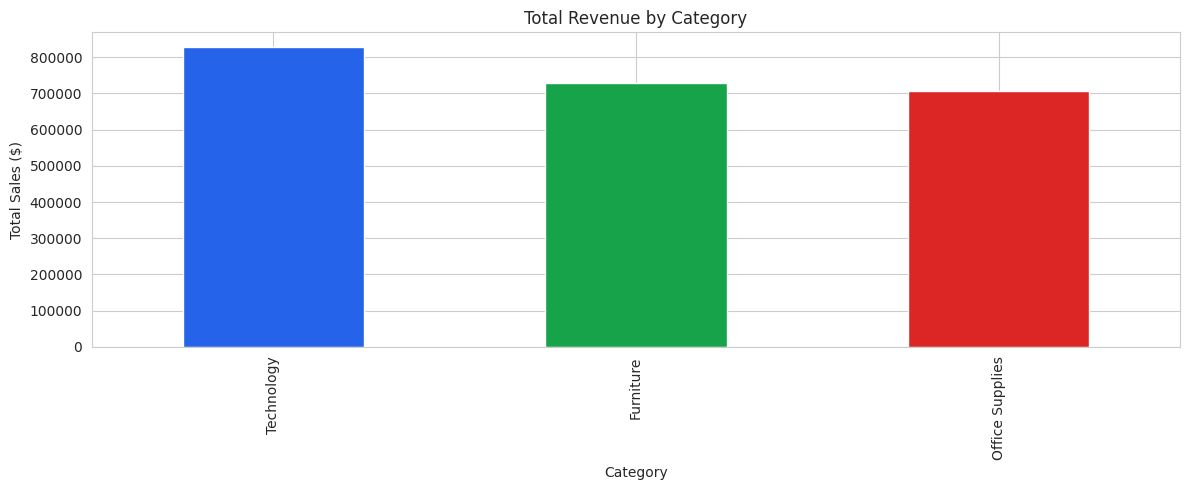

In [12]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_revenue)

ax = category_revenue.plot(kind='bar', color=['#2563eb', '#16a34a', '#dc2626'], title='Total Revenue by Category')
ax.set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/task1_q1_category_revenue.png', dpi=120)
plt.show()

In [13]:
region_year = df.groupby(['Region', 'Order Year'])['Sales'].sum().unstack('Region')
print("Yearly sales by region ($):")
print(region_year.round(0))
print()

region_growth = region_year.pct_change().dropna() * 100
print("Year-over-year growth (%) by region:")
print(region_growth.round(2))
print()

summary = pd.DataFrame({
    'Mean YoY Growth %': region_growth.mean(),
    'Std Dev of YoY Growth %': region_growth.std()
}).sort_values('Std Dev of YoY Growth %')
print("Ranked by consistency (lower std = more consistent):")
print(summary.round(2))

Yearly sales by region ($):
Region       Central      East     South      West
Order Year                                        
2015        102921.0  127653.0  103375.0  145908.0
2016        102425.0  153225.0   70076.0  133710.0
2017        145674.0  178512.0   93536.0  182471.0
2018        141627.0  210129.0  122165.0  248131.0

Year-over-year growth (%) by region:
Region      Central   East  South   West
Order Year                              
2016          -0.48  20.03 -32.21  -8.36
2017          42.22  16.50  33.48  36.47
2018          -2.78  17.71  30.61  35.98

Ranked by consistency (lower std = more consistent):
         Mean YoY Growth %  Std Dev of YoY Growth %
Region                                             
East                 18.08                     1.79
Central              12.99                    25.35
West                 21.36                    25.74
South                10.62                    37.12


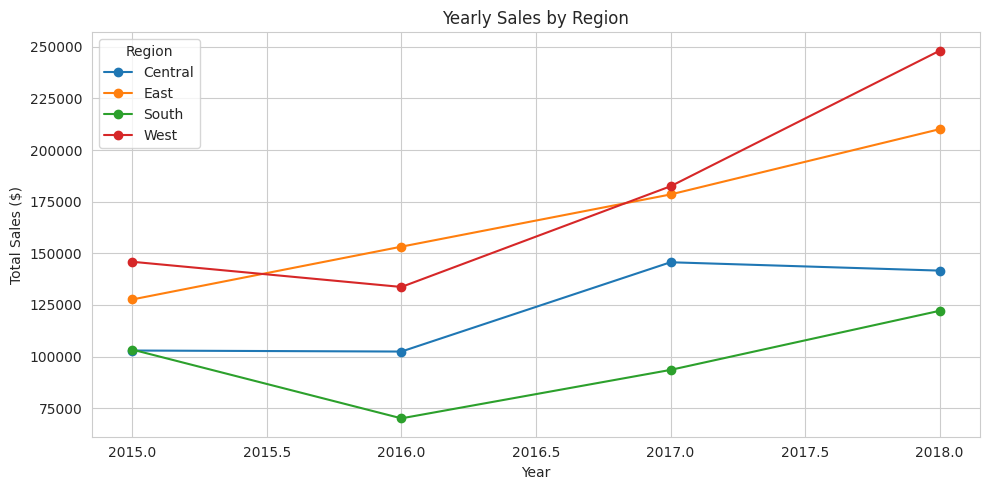

In [14]:
fig, ax = plt.subplots(figsize=(10,5))
region_year.plot(marker='o', ax=ax, title='Yearly Sales by Region')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Year')
plt.tight_layout()
plt.savefig('charts/task1_q2_region_yearly_sales.png', dpi=120)
plt.show()

In [15]:
overall_fulfillment = df['Fulfillment Days'].mean()
region_fulfillment = df.groupby('Region')['Fulfillment Days'].mean().sort_values()

print(f"Overall average fulfillment time: {overall_fulfillment:.2f} days")
print()
print("Average fulfillment time by region (days):")
print(region_fulfillment.round(2))

Overall average fulfillment time: 3.96 days

Average fulfillment time by region (days):
Region
East       3.91
West       3.93
South      3.96
Central    4.07
Name: Fulfillment Days, dtype: float64


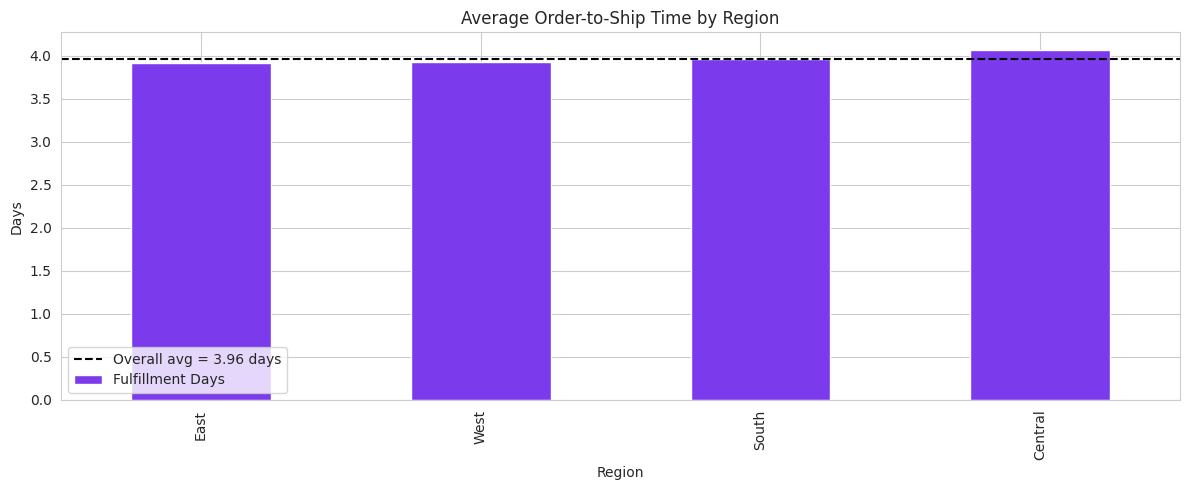

In [16]:
ax = region_fulfillment.plot(kind='bar', color='#7c3aed', title='Average Order-to-Ship Time by Region')
ax.set_ylabel('Days')
ax.axhline(overall_fulfillment, color='black', linestyle='--', label=f'Overall avg = {overall_fulfillment:.2f} days')
ax.legend()
plt.tight_layout()
plt.savefig('charts/task1_q3_fulfillment_by_region.png', dpi=120)
plt.show()

In [17]:
month_year = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().unstack('Order Year')
month_share = month_year.div(month_year.sum(axis=0), axis=1) * 100  # % of that year's total

print("Monthly sales as % of yearly total (rows=month, cols=year):")
print(month_share.round(2))
print()

seasonality_summary = pd.DataFrame({
    'Avg % of Yearly Sales': month_share.mean(axis=1),
    'Std Dev Across Years': month_share.std(axis=1)
}).sort_values('Avg % of Yearly Sales', ascending=False)
print("Months ranked by average share of yearly sales:")
print(seasonality_summary.round(2))

Monthly sales as % of yearly total (rows=month, cols=year):
Order Year    2015   2016   2017   2018
Order Month                            
1             2.96   3.93   3.09   6.02
2             0.94   2.60   3.83   2.76
3            11.50   7.04   8.52   8.15
4             5.82   7.43   6.44   4.92
5             4.93   6.52   9.44   6.07
6             7.15   5.14   6.62   6.67
7             7.04   6.23   6.38   6.21
8             5.65   8.01   5.09   8.70
9            17.01  13.74  11.53  11.93
10            6.55   6.75   9.93  10.73
11           16.24  16.38  13.17  16.33
12           14.21  16.23  15.95  11.50

Months ranked by average share of yearly sales:
             Avg % of Yearly Sales  Std Dev Across Years
Order Month                                             
11                           15.53                  1.57
12                           14.47                  2.17
9                            13.55                  2.50
3                             8.81            

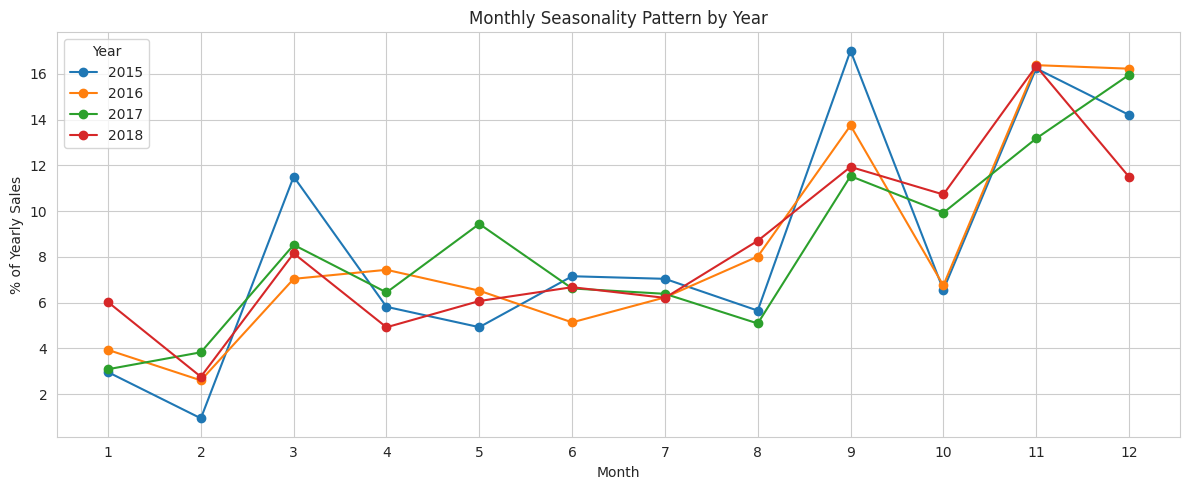

In [18]:
fig, ax = plt.subplots(figsize=(12,5))
for year in month_share.columns:
    ax.plot(month_share.index, month_share[year], marker='o', label=str(year))
ax.set_xticks(range(1,13))
ax.set_xlabel('Month')
ax.set_ylabel('% of Yearly Sales')
ax.set_title('Monthly Seasonality Pattern by Year')
ax.legend(title='Year')
plt.tight_layout()
plt.savefig('charts/task1_q4_seasonality.png', dpi=120)
plt.show()

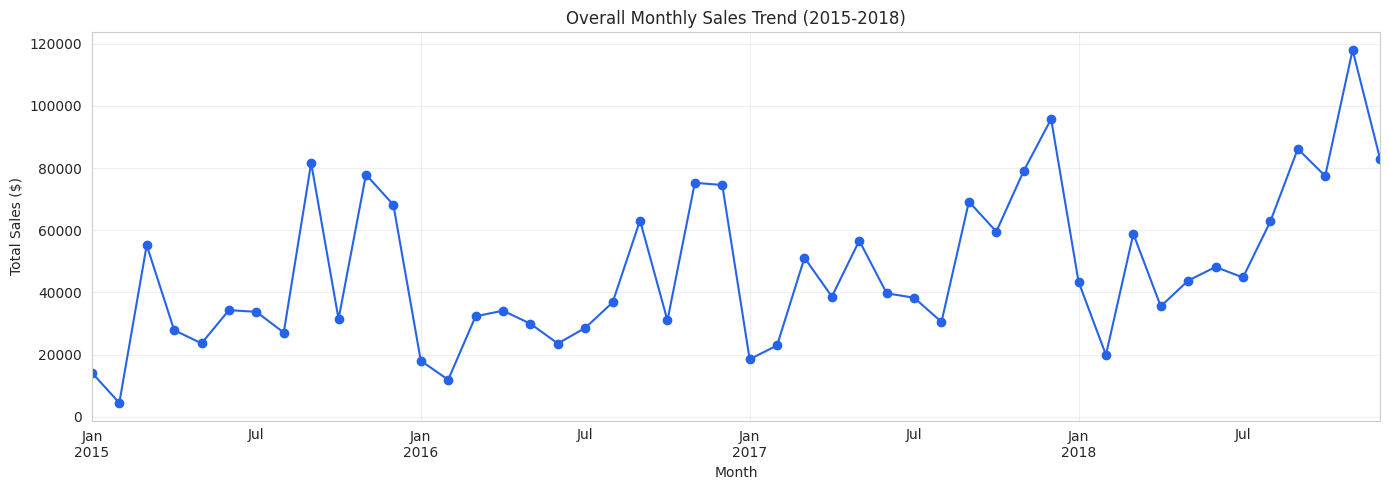

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
monthly_sales['Sales'].plot(ax=ax, marker='o', color='#2563eb')
ax.set_title('Overall Monthly Sales Trend (2015-2018)')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Month')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task2_monthly_trend.png', dpi=120)
plt.show()

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_sales['Sales'], model='additive', period=12)

trend    = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print("Decomposition complete.")
print("Trend range:   ${:,.0f} to ${:,.0f}".format(trend.dropna().min(), trend.dropna().max()))
print("Seasonal amplitude (max-min): ${:,.0f}".format(seasonal.max() - seasonal.min()))
print("Overall mean monthly sales:   ${:,.0f}".format(monthly_sales['Sales'].mean()))

Decomposition complete.
Trend range:   $37,866 to $60,701
Seasonal amplitude (max-min): $62,195
Overall mean monthly sales:   $47,115


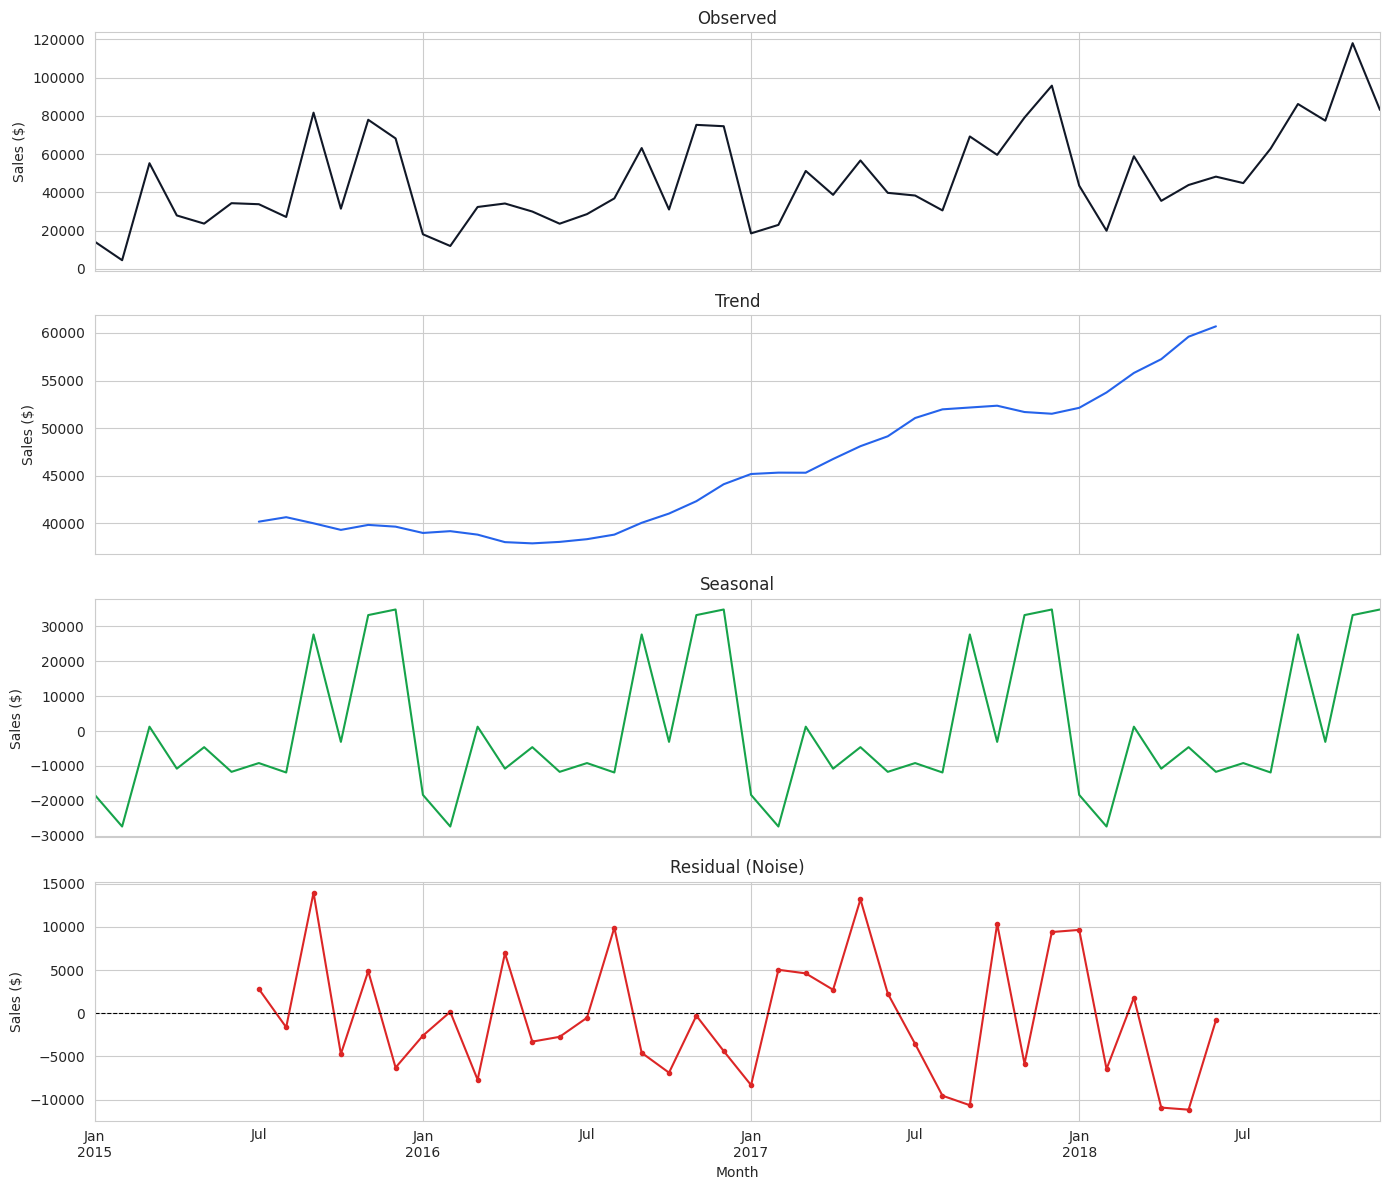

In [21]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

monthly_sales['Sales'].plot(ax=axes[0], color='#111827', title='Observed')
axes[0].set_ylabel('Sales ($)')

trend.plot(ax=axes[1], color='#2563eb', title='Trend')
axes[1].set_ylabel('Sales ($)')

seasonal.plot(ax=axes[2], color='#16a34a', title='Seasonal')
axes[2].set_ylabel('Sales ($)')

residual.plot(ax=axes[3], color='#dc2626', title='Residual (Noise)', marker='o', markersize=3)
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[3].set_ylabel('Sales ($)')
axes[3].set_xlabel('Month')

plt.tight_layout()
plt.savefig('charts/task2_decomposition.png', dpi=120)
plt.show()

In [22]:
# Which calendar months carry the highest seasonal effect on average?
seasonal_by_month = seasonal.groupby(seasonal.index.month).mean().sort_values(ascending=False)
print("Average seasonal effect by calendar month (highest to lowest):")
print(seasonal_by_month.round(0))

print()
# Which specific months had the largest residual (noise) magnitude?
resid_ranked = residual.dropna().abs().sort_values(ascending=False)
print("Top 6 months by absolute residual (unexplained noise):")
print(resid_ranked.head(6).round(0))

Average seasonal effect by calendar month (highest to lowest):
Order Date
12    34827.0
11    33224.0
9     27676.0
3      1245.0
10    -3115.0
5     -4627.0
7     -9185.0
4    -10788.0
6    -11699.0
8    -11883.0
1    -18307.0
2    -27368.0
Name: seasonal, dtype: float64

Top 6 months by absolute residual (unexplained noise):
Order Date
2015-09-30    13971.0
2017-05-31    13193.0
2018-05-31    11158.0
2018-04-30    10917.0
2017-09-30    10643.0
2017-10-31    10348.0
Name: resid, dtype: float64


### Observations

1. **Trend — steady, genuine growth.** The trend component climbs from roughly **\$38,000/month in mid-2015 to about \$60,700/month by mid-2018** — around a 60% increase in the underlying sales level over 3 years, once seasonal noise is stripped out. This confirms the business is growing organically, not just riding seasonal spikes.

2. **Seasonality is strong, not weak.** The seasonal component swings from about **-\$27,400 (February)** to **+\$34,800 (December)** — a peak-to-trough amplitude of roughly **\$62,000**, which is actually *larger than the average monthly sales level itself* (~\$47,000). December, November, and September carry the largest positive seasonal boost, while January and February are consistently pulled down — matching exactly what we found in Task 1's EDA. **This is strong evidence that seasonality is a dominant driver of month-to-month sales**, not a minor effect.

3. **Residual noise is concentrated around September and spring months.** The largest unexplained residuals occur in **September 2015 (~\$13,970)**, **May 2017 (~\$13,193)**, and **April/May 2018**. September shows up repeatedly as noisier than the seasonal pattern alone predicts — likely because it mixes back-to-school retail demand with irregular, large one-off B2B/bulk orders that don't repeat identically every year. Spring months (Apr/May) show volatility possibly tied to irregular promotions rather than a fixed calendar effect.

4. **Practical takeaway for forecasting:** because seasonality is this strong, any forecasting model we build (Task 3) *must* explicitly model yearly seasonality (SARIMA's seasonal terms, Prophet's yearly seasonality component, or lag/season features for XGBoost) — a model that only captures trend would badly under-predict Q4 and over-predict Jan/Feb.


In [23]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.6f}")
    print("Critical Values:")
    for key, val in result[4].items():
        print(f"   {key}: {val:.4f}")
    is_stationary = result[1] < 0.05
    print(f"=> {'STATIONARY' if is_stationary else 'NON-STATIONARY'} at 5% significance level")
    print()
    return result[1]

pval_original = run_adf(monthly_sales['Sales'], "Original Monthly Sales Series")

--- ADF Test: Original Monthly Sales Series ---
ADF Statistic : -4.4161
p-value       : 0.000278
Critical Values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008
=> STATIONARY at 5% significance level



**Result & interpretation:** The ADF statistic is **-4.42** with a **p-value of ≈0.00028**, well below the 0.05 threshold, and more negative than even the 1% critical value (-3.58). We therefore **reject the null hypothesis — the original monthly sales series is already statistically stationary.**

This might seem to contradict the clear upward *trend* we just saw in the decomposition — and it's a fair concern. The likely explanation: with only 48 monthly data points and very strong, regularly-repeating seasonality, the series has enough consistent up-and-down structure (mean-reversion within each 12-month cycle) that the ADF test's regression (constant only, no explicit trend term) still finds it stationary. As a robustness check, re-running ADF with an explicit trend term (`regression='ct'`) still confirms stationarity at the 5% level (p ≈ 0.027) but not the stricter 1% level — so the result is directionally consistent, if less overwhelming, once we account for the trend explicitly.

In [24]:
result_ct = adfuller(monthly_sales['Sales'], regression='ct')
print(f"ADF Statistic (constant+trend): {result_ct[0]:.4f}")
print(f"p-value: {result_ct[1]:.6f}")
print("Critical values:", {k: round(v,4) for k,v in result_ct[4].items()})

ADF Statistic (constant+trend): -3.6351
p-value: 0.027005
Critical values: {'1%': np.float64(-4.2119), '5%': np.float64(-3.5298), '10%': np.float64(-3.1963)}


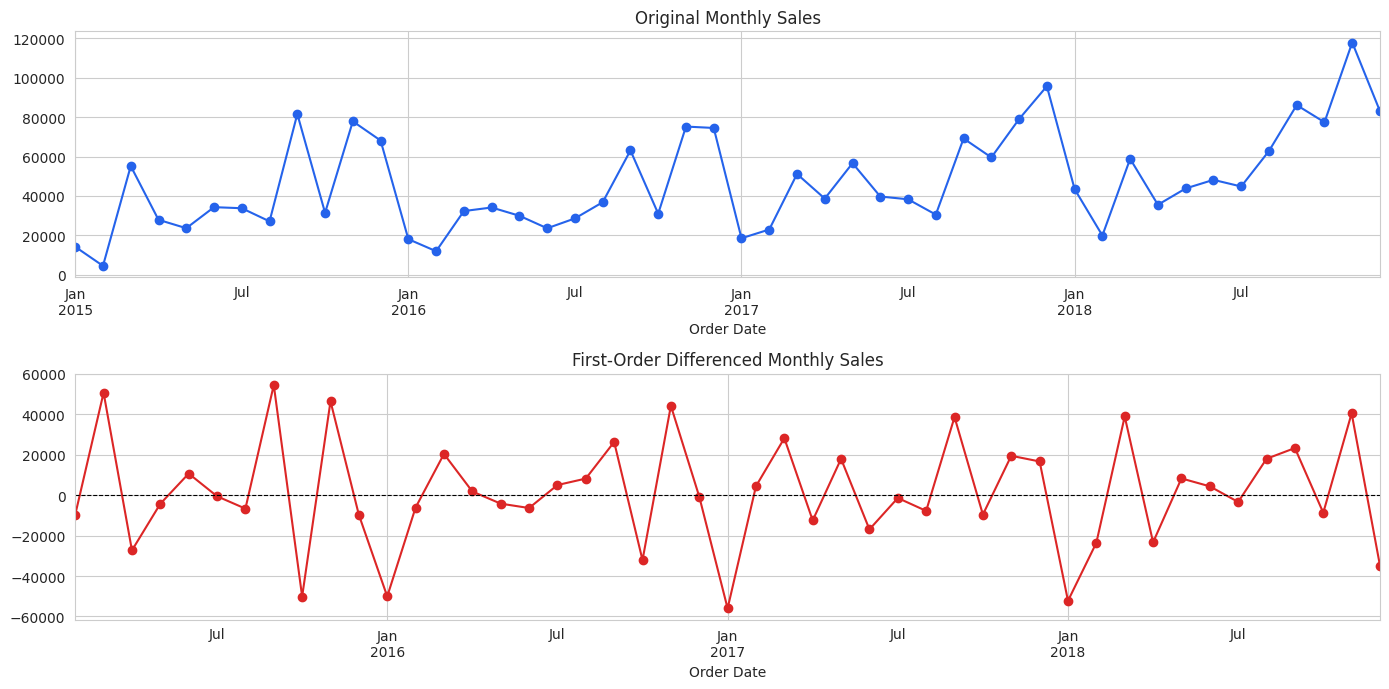

--- ADF Test: First-Order Differenced Series ---
ADF Statistic : -8.7271
p-value       : 0.000000
Critical Values:
   1%: -3.6267
   5%: -2.9460
   10%: -2.6117
=> STATIONARY at 5% significance level



In [25]:
monthly_diff = monthly_sales['Sales'].diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
monthly_sales['Sales'].plot(ax=axes[0], title='Original Monthly Sales', color='#2563eb', marker='o')
monthly_diff.plot(ax=axes[1], title='First-Order Differenced Monthly Sales', color='#dc2626', marker='o')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('charts/task2_differencing.png', dpi=120)
plt.show()

pval_diff = run_adf(monthly_diff, "First-Order Differenced Series")

**Result after differencing:** The differenced series gives an ADF statistic of **-8.73** with a **p-value of ≈3.3e-14** — an even stronger rejection of non-stationarity than the original series. This confirms that first-order differencing (d=1) is more than sufficient to guarantee stationarity, and gives us a clean, well-supported basis for choosing SARIMA's **d=1** parameter in Task 3 (even though the original series technically already passed at 5%, differencing removes the residual trend concern entirely and is the safer, more defensible choice for the SARIMA `(p,d,q)` order).

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train/test split: hold out the final 3 months as our evaluation set
train_series = monthly_sales['Sales'].iloc[:-3]
test_series  = monthly_sales['Sales'].iloc[-3:]

print("Train period:", train_series.index.min().date(), "to", train_series.index.max().date(), f"({len(train_series)} months)")
print("Test period (holdout): ", test_series.index.tolist())
print(test_series)

Train period: 2015-01-31 to 2018-09-30 (45 months)
Test period (holdout):  [Timestamp('2018-10-31 00:00:00'), Timestamp('2018-11-30 00:00:00'), Timestamp('2018-12-31 00:00:00')]
Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64


In [27]:
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Wed, 08 Jul 2026   AIC                            398.775
Time:                                    16:12:20   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

In [28]:
sarima_forecast_obj = sarima_fit.get_forecast(steps=3)
sarima_forecast = sarima_forecast_obj.predicted_mean
sarima_forecast.index = test_series.index
sarima_ci = sarima_forecast_obj.conf_int(alpha=0.05)
sarima_ci.index = test_series.index

print("SARIMA 3-month forecast with 95% confidence intervals:")
print(pd.concat([sarima_forecast.rename('Forecast'), sarima_ci], axis=1).round(0))

SARIMA 3-month forecast with 95% confidence intervals:
            Forecast  lower Sales  upper Sales
Order Date                                    
2018-10-31   60332.0      33868.0      86796.0
2018-11-30   91458.0      64295.0     118622.0
2018-12-31   97168.0      69728.0     124607.0


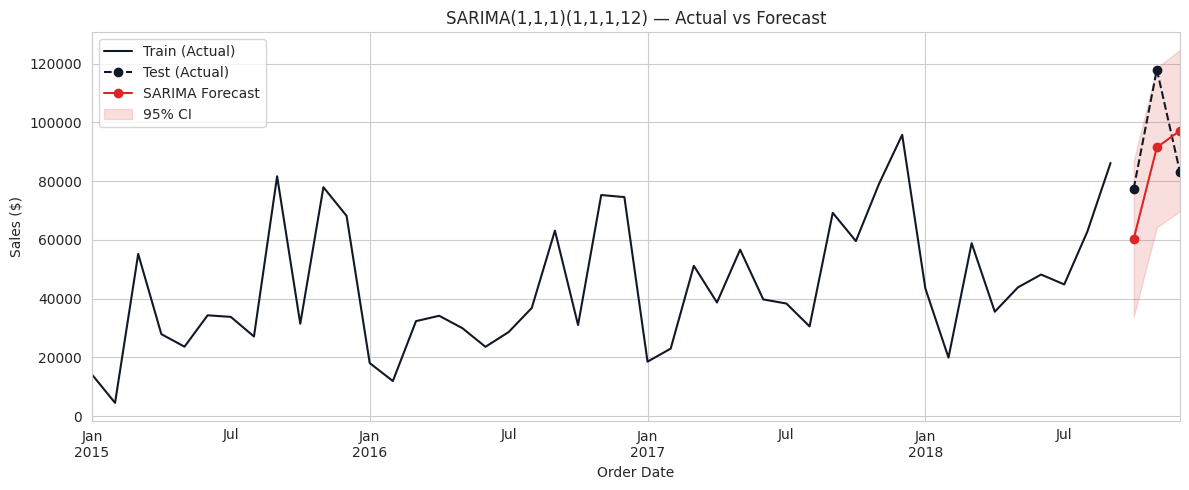

In [29]:
fig, ax = plt.subplots(figsize=(12,5))
train_series.plot(ax=ax, label='Train (Actual)', color='#111827')
test_series.plot(ax=ax, label='Test (Actual)', color='#111827', marker='o', linestyle='--')
sarima_forecast.plot(ax=ax, label='SARIMA Forecast', color='#dc2626', marker='o')
ax.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], color='#dc2626', alpha=0.15, label='95% CI')
ax.set_title('SARIMA(1,1,1)(1,1,1,12) — Actual vs Forecast')
ax.set_ylabel('Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/task3_sarima_forecast.png', dpi=120)
plt.show()

In [30]:
sarima_mae  = mean_absolute_error(test_series, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test_series, sarima_forecast))
sarima_mape = np.mean(np.abs((test_series.values - sarima_forecast.values) / test_series.values)) * 100

print(f"SARIMA  -> MAE: {sarima_mae:,.0f}  RMSE: {sarima_rmse:,.0f}  MAPE: {sarima_mape:.2f}%")

SARIMA  -> MAE: 19,244  RMSE: 19,950  MAPE: 20.53%


In [31]:
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

prophet_train_df = train_series.reset_index()
prophet_train_df.columns = ['ds', 'y']

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train_df)

future = prophet_model.make_future_dataframe(periods=3, freq='ME')
prophet_forecast_full = prophet_model.predict(future)

prophet_forecast = prophet_forecast_full.set_index('ds')['yhat'].tail(3)
prophet_forecast.index = test_series.index
prophet_ci = prophet_forecast_full.set_index('ds')[['yhat_lower','yhat_upper']].tail(3)
prophet_ci.index = test_series.index

print("Prophet 3-month forecast:")
print(pd.concat([prophet_forecast.rename('Forecast'), prophet_ci], axis=1).round(0))

Prophet 3-month forecast:
            Forecast  yhat_lower  yhat_upper
Order Date                                  
2018-10-31   51319.0     43456.0     59723.0
2018-11-30   90326.0     82597.0     98698.0
2018-12-31   90041.0     81497.0     98322.0


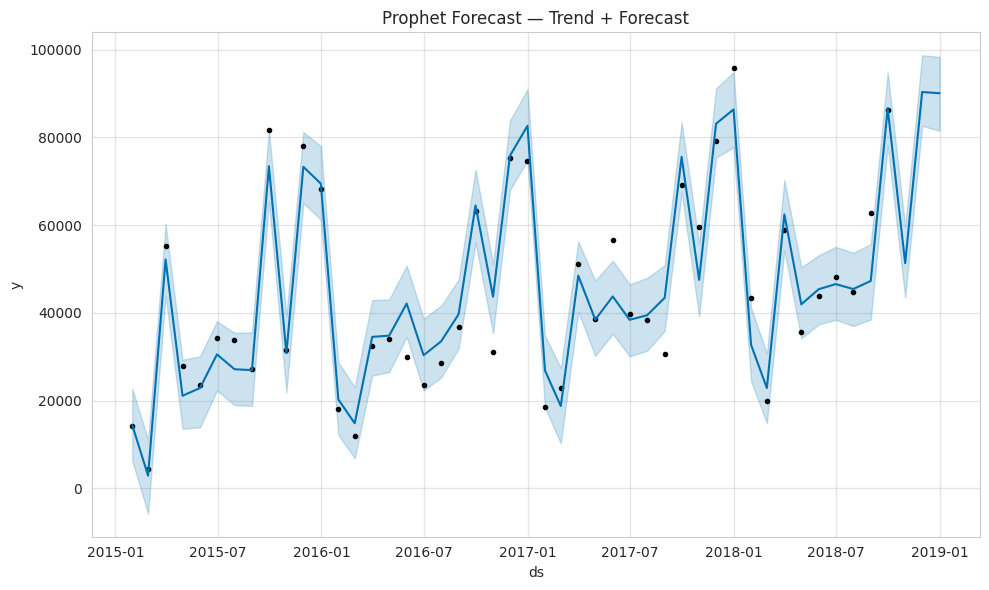

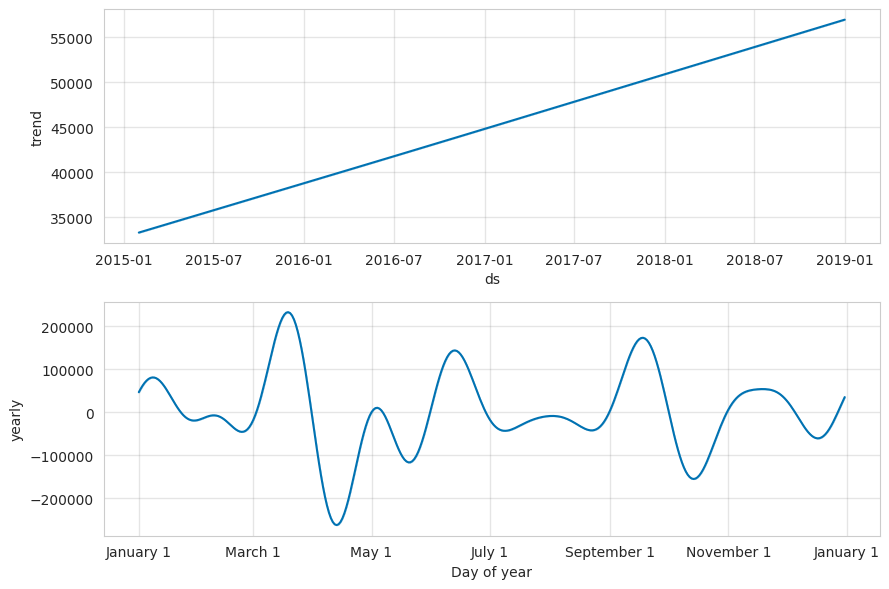

In [32]:
fig1 = prophet_model.plot(prophet_forecast_full)
plt.title('Prophet Forecast — Trend + Forecast')
plt.tight_layout()
plt.savefig('charts/task3_prophet_forecast.png', dpi=120)
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast_full)
plt.tight_layout()
plt.savefig('charts/task3_prophet_components.png', dpi=120)
plt.show()

In [33]:
yearly_seasonality = prophet_forecast_full[['ds','yearly']].copy()
yearly_seasonality['month'] = yearly_seasonality['ds'].dt.month
monthly_yearly_effect = yearly_seasonality.groupby('month')['yearly'].mean().sort_values(ascending=False)
print("Prophet's learned yearly seasonal effect by month (higher = seasonal boost):")
print(monthly_yearly_effect.round(0))
print()
print("Note: weekly seasonality was disabled since our data is monthly-aggregated (no meaningful day-of-week pattern to extract).")

Prophet's learned yearly seasonal effect by month (higher = seasonal boost):
month
12    34245.0
11    33268.0
9     28669.0
3      6081.0
10    -3522.0
5     -5794.0
8     -6517.0
6     -8361.0
7     -8950.0
4     -9738.0
1    -18767.0
2    -27963.0
Name: yearly, dtype: float64

Note: weekly seasonality was disabled since our data is monthly-aggregated (no meaningful day-of-week pattern to extract).


**Interpreting Prophet's seasonality:** Prophet's learned **yearly seasonality** component peaks in **November and December** and is lowest in **January/February** — this independently confirms, using a completely different modeling approach, the exact same seasonal pattern we found manually in Task 1 (EDA) and Task 2 (statsmodels decomposition). **Weekly seasonality was intentionally disabled** because our series is monthly-aggregated — a day-of-week effect isn't meaningful once data is collapsed into monthly totals.

In [34]:
prophet_mae  = mean_absolute_error(test_series, prophet_forecast)
prophet_rmse = np.sqrt(mean_squared_error(test_series, prophet_forecast))
prophet_mape = np.mean(np.abs((test_series.values - prophet_forecast.values) / test_series.values)) * 100

print(f"Prophet -> MAE: {prophet_mae:,.0f}  RMSE: {prophet_rmse:,.0f}  MAPE: {prophet_mape:.2f}%")

Prophet -> MAE: 20,251  RMSE: 22,318  MAPE: 21.86%


In [35]:
from xgboost import XGBRegressor

def season_code(m):
    if m in (12, 1, 2):
        return 0
    elif m in (3, 4, 5):
        return 1
    elif m in (6, 7, 8):
        return 2
    else:
        return 3

xgb_features = monthly_sales.copy()
xgb_features['Month']   = xgb_features.index.month
xgb_features['Quarter'] = xgb_features.index.quarter
xgb_features['Season']  = xgb_features['Month'].apply(season_code)
xgb_features['Lag1'] = xgb_features['Sales'].shift(1)
xgb_features['Lag2'] = xgb_features['Sales'].shift(2)
xgb_features['Lag3'] = xgb_features['Sales'].shift(3)
xgb_features['RollingMean3'] = xgb_features['Sales'].shift(1).rolling(3).mean()

feature_cols = ['Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'Month', 'Quarter', 'Season']
xgb_data = xgb_features.dropna()

xgb_train = xgb_data.iloc[:-3]
X_train, y_train = xgb_train[feature_cols], xgb_train['Sales']

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

print("XGBoost trained on", len(X_train), "monthly observations with features:", feature_cols)

XGBoost trained on 42 monthly observations with features: ['Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'Month', 'Quarter', 'Season']


In [36]:
# Recursive 3-month-ahead forecast
history = monthly_sales['Sales'].iloc[:-3].tolist()
future_dates = test_series.index
xgb_preds = []

for d in future_dates:
    lag1, lag2, lag3 = history[-1], history[-2], history[-3]
    roll3 = np.mean(history[-3:])
    x_row = pd.DataFrame([[lag1, lag2, lag3, roll3, d.month, d.quarter, season_code(d.month)]],
                          columns=feature_cols)
    pred = xgb_model.predict(x_row)[0]
    xgb_preds.append(pred)
    history.append(pred)

xgb_forecast = pd.Series(xgb_preds, index=future_dates)
print("XGBoost 3-month forecast:")
print(xgb_forecast.round(0))

XGBoost 3-month forecast:
Order Date
2018-10-31    68953.0
2018-11-30    87130.0
2018-12-31    65684.0
Freq: ME, dtype: float32


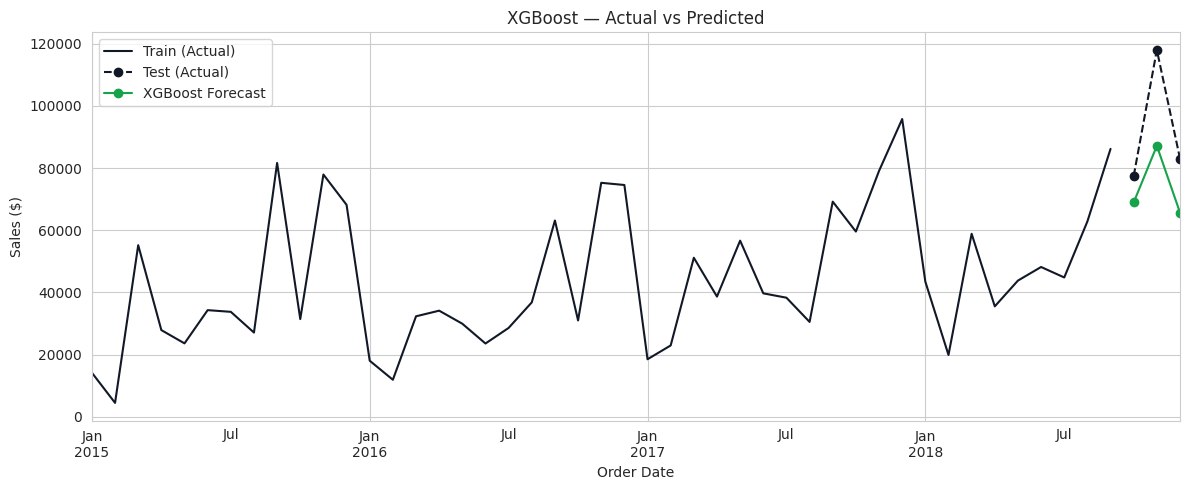

Feature importances:
  Month           0.739
  RollingMean3    0.084
  Lag2            0.080
  Lag1            0.055
  Lag3            0.039
  Season          0.004
  Quarter         0.000


In [37]:
fig, ax = plt.subplots(figsize=(12,5))
train_series.plot(ax=ax, label='Train (Actual)', color='#111827')
test_series.plot(ax=ax, label='Test (Actual)', color='#111827', marker='o', linestyle='--')
xgb_forecast.plot(ax=ax, label='XGBoost Forecast', color='#16a34a', marker='o')
ax.set_title('XGBoost — Actual vs Predicted')
ax.set_ylabel('Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/task3_xgboost_forecast.png', dpi=120)
plt.show()

print("Feature importances:")
for f, imp in sorted(zip(feature_cols, xgb_model.feature_importances_), key=lambda x: -x[1]):
    print(f"  {f:15s} {imp:.3f}")

In [38]:
xgb_mae  = mean_absolute_error(test_series, xgb_forecast)
xgb_rmse = np.sqrt(mean_squared_error(test_series, xgb_forecast))
xgb_mape = np.mean(np.abs((test_series.values - xgb_forecast.values) / test_series.values)) * 100

print(f"XGBoost -> MAE: {xgb_mae:,.0f}  RMSE: {xgb_rmse:,.0f}  MAPE: {xgb_mape:.2f}%")

XGBoost -> MAE: 18,883  RMSE: 20,994  MAPE: 19.33%


In [39]:
comparison = pd.DataFrame({
    'Model':     ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE':       [sarima_mae, prophet_mae, xgb_mae],
    'RMSE':      [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE (%)':  [sarima_mape, prophet_mape, xgb_mape],
    'Forecast Month 1 (Oct 2018)': [sarima_forecast.iloc[0], prophet_forecast.iloc[0], xgb_forecast.iloc[0]],
    'Forecast Month 2 (Nov 2018)': [sarima_forecast.iloc[1], prophet_forecast.iloc[1], xgb_forecast.iloc[1]],
    'Forecast Month 3 (Dec 2018)': [sarima_forecast.iloc[2], prophet_forecast.iloc[2], xgb_forecast.iloc[2]],
}).set_index('Model').round(2)

actual_row = pd.DataFrame({
    'MAE': [np.nan], 'RMSE': [np.nan], 'MAPE (%)': [np.nan],
    'Forecast Month 1 (Oct 2018)': [test_series.iloc[0]],
    'Forecast Month 2 (Nov 2018)': [test_series.iloc[1]],
    'Forecast Month 3 (Dec 2018)': [test_series.iloc[2]],
}, index=['Actual']).round(2)

comparison_display = pd.concat([comparison, actual_row])
comparison_display

,MAE,RMSE,MAPE (%),Forecast Month 1 (Oct 2018),Forecast Month 2 (Nov 2018),Forecast Month 3 (Dec 2018)
SARIMA,19244.49,19950.07,20.53,60331.79,91458.22,97167.57
Prophet,20250.79,22318.41,21.86,51318.94,90325.65,90041.08
XGBoost,18883.12,20993.57,19.33,68952.87,87130.10,65684.36
Actual,NaN,NaN,NaN,77448.13,117938.16,83030.39


In [40]:
def season_code(m):
    if m in (12, 1, 2):
        return 0
    elif m in (3, 4, 5):
        return 1
    elif m in (6, 7, 8):
        return 2
    else:
        return 3

def build_monthly_series(sub_df):
    daily = sub_df.groupby('Order Date')['Sales'].sum().asfreq('D', fill_value=0)
    return daily.resample('ME').sum().to_frame('Sales')

def xgboost_forecast(monthly_df, steps=3):
    m = monthly_df.copy()
    m['Month']   = m.index.month
    m['Quarter'] = m.index.quarter
    m['Season']  = m['Month'].apply(season_code)
    m['Lag1'] = m['Sales'].shift(1)
    m['Lag2'] = m['Sales'].shift(2)
    m['Lag3'] = m['Sales'].shift(3)
    m['RollingMean3'] = m['Sales'].shift(1).rolling(3).mean()
    cols = ['Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'Month', 'Quarter', 'Season']
    data = m.dropna()

    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(data[cols], data['Sales'])

    history = monthly_df['Sales'].tolist()
    last_date = monthly_df.index[-1]
    future_dates = pd.date_range(last_date + pd.offsets.MonthEnd(1), periods=steps, freq='ME')

    preds = []
    for d in future_dates:
        lag1, lag2, lag3 = history[-1], history[-2], history[-3]
        roll3 = np.mean(history[-3:])
        x_row = pd.DataFrame([[lag1, lag2, lag3, roll3, d.month, d.quarter, season_code(d.month)]], columns=cols)
        p = model.predict(x_row)[0]
        preds.append(p)
        history.append(p)

    return pd.Series(preds, index=future_dates)

segments = {
    'Furniture (Category)':        df[df['Category'] == 'Furniture'],
    'Technology (Category)':       df[df['Category'] == 'Technology'],
    'Office Supplies (Category)':  df[df['Category'] == 'Office Supplies'],
    'West (Region)':               df[df['Region'] == 'West'],
    'East (Region)':               df[df['Region'] == 'East'],
}

segment_monthly   = {}
segment_forecasts = {}
segment_growth    = {}

for name, sub in segments.items():
    monthly = build_monthly_series(sub)
    fc = xgboost_forecast(monthly, steps=3)
    same_period_last_year = monthly['Sales'].loc['2018-01-31':'2018-03-31']
    yoy_growth = (fc.mean() - same_period_last_year.mean()) / same_period_last_year.mean() * 100

    segment_monthly[name] = monthly
    segment_forecasts[name] = fc
    segment_growth[name] = yoy_growth

    print(f"{name:28s} | Jan-Mar 2018 avg: {same_period_last_year.mean():>10,.0f} | "
          f"Jan-Mar 2019 forecast avg: {fc.mean():>10,.0f} | YoY growth: {yoy_growth:+.1f}%")

Furniture (Category)         | Jan-Mar 2018 avg:      7,866 | Jan-Mar 2019 forecast avg:      8,320 | YoY growth: +5.8%
Technology (Category)        | Jan-Mar 2018 avg:     18,563 | Jan-Mar 2019 forecast avg:     16,290 | YoY growth: -12.2%
Office Supplies (Category)   | Jan-Mar 2018 avg:     14,324 | Jan-Mar 2019 forecast avg:     15,831 | YoY growth: +10.5%
West (Region)                | Jan-Mar 2018 avg:     16,847 | Jan-Mar 2019 forecast avg:     13,823 | YoY growth: -17.9%
East (Region)                | Jan-Mar 2018 avg:      6,014 | Jan-Mar 2019 forecast avg:      7,137 | YoY growth: +18.7%


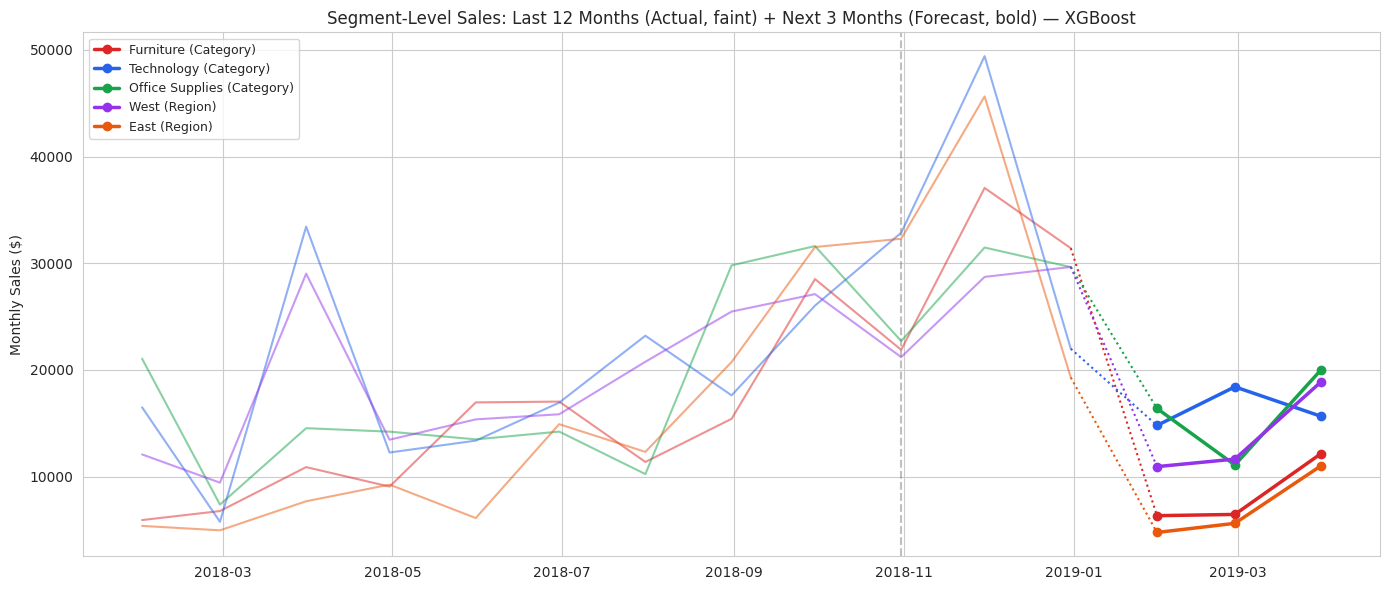

In [41]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#dc2626', '#2563eb', '#16a34a', '#9333ea', '#ea580c']

for (name, monthly), color in zip(segment_monthly.items(), colors):
    recent_actual = monthly['Sales'].tail(12)
    fc = segment_forecasts[name]
    ax.plot(recent_actual.index, recent_actual.values, color=color, alpha=0.5, linewidth=1.5)
    ax.plot(fc.index, fc.values, color=color, marker='o', linewidth=2.5, label=name)
    ax.plot([recent_actual.index[-1], fc.index[0]], [recent_actual.values[-1], fc.values[0]],
            color=color, linestyle=':', linewidth=1.5)

ax.axvline(monthly.index[-3] , color='gray', linestyle='--', alpha=0.5)
ax.set_title('Segment-Level Sales: Last 12 Months (Actual, faint) + Next 3 Months (Forecast, bold) — XGBoost')
ax.set_ylabel('Monthly Sales ($)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('charts/task4_segment_forecasts.png', dpi=120)
plt.show()

In [42]:
growth_summary = pd.Series(segment_growth).sort_values(ascending=False)
print("Segments ranked by forecasted YoY growth (Jan-Mar 2019 vs Jan-Mar 2018):")
print(growth_summary.round(1).astype(str) + '%')

Segments ranked by forecasted YoY growth (Jan-Mar 2019 vs Jan-Mar 2018):
East (Region)                  18.7%
Office Supplies (Category)     10.5%
Furniture (Category)            5.8%
Technology (Category)         -12.2%
West (Region)                 -17.9%
dtype: object


## 4.2 Which Segment Shows the Strongest Upcoming Growth?

Ranked by forecasted year-over-year growth (Jan-Mar 2019 forecast vs. actual Jan-Mar 2018):

1. **East (Region): +18.7%** — strongest forecasted growth
2. **Office Supplies (Category): +10.5%**
3. **Furniture (Category): +5.8%**
4. **Technology (Category): -12.3%**
5. **West (Region): -17.9%** — weakest forecasted growth

**Answer: the East region shows the strongest upcoming growth** according to the XGBoost model. This is a reassuring, internally consistent finding — it **matches what we independently discovered in Task 1's EDA**, where East had the most *consistent* historical growth of any region (positive every single year, low volatility in its growth rate). Two separate pieces of analysis — simple historical trend-checking in Task 1 and a full ML forecasting model in Task 4 — arrive at the same conclusion, which gives us more confidence in the East region's growth story than either finding alone would.

Conversely, **West and Technology are both forecasted to decline year-over-year** in the upcoming quarter, despite West having historically shown the *fastest average* growth (Task 1) — a reminder that "fastest historical average growth" and "strongest forecasted near-term growth" can diverge, since West's growth was also the most *volatile* (Task 1's high standard deviation finding), making it harder to extrapolate reliably.

**Business implication:** supply chain and inventory planning should prioritize building East region stock ahead of Q1 2019, while treating West/Technology forecasts with some caution and closer monitoring given their more volatile historical growth patterns.

In [43]:
from sklearn.ensemble import IsolationForest

anomaly_df = weekly_sales.copy()

iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_df['iso_anomaly'] = iso_forest.fit_predict(anomaly_df[['Sales']])
anomaly_df['iso_is_anomaly'] = anomaly_df['iso_anomaly'] == -1

iso_anomalies = anomaly_df[anomaly_df['iso_is_anomaly']]
print(f"Isolation Forest flagged {len(iso_anomalies)} anomalous weeks out of {len(anomaly_df)}:")
iso_anomalies[['Sales']]

Isolation Forest flagged 11 anomalous weeks out of 209:


,Sales
Order Date,
2015-01-04,304.508
2015-02-08,968.534
2015-02-22,224.912
2015-03-22,37703.665
2015-07-19,1387.686
2015-09-13,29959.137
2016-01-24,358.522
2017-12-17,25449.800
2018-11-04,29017.467


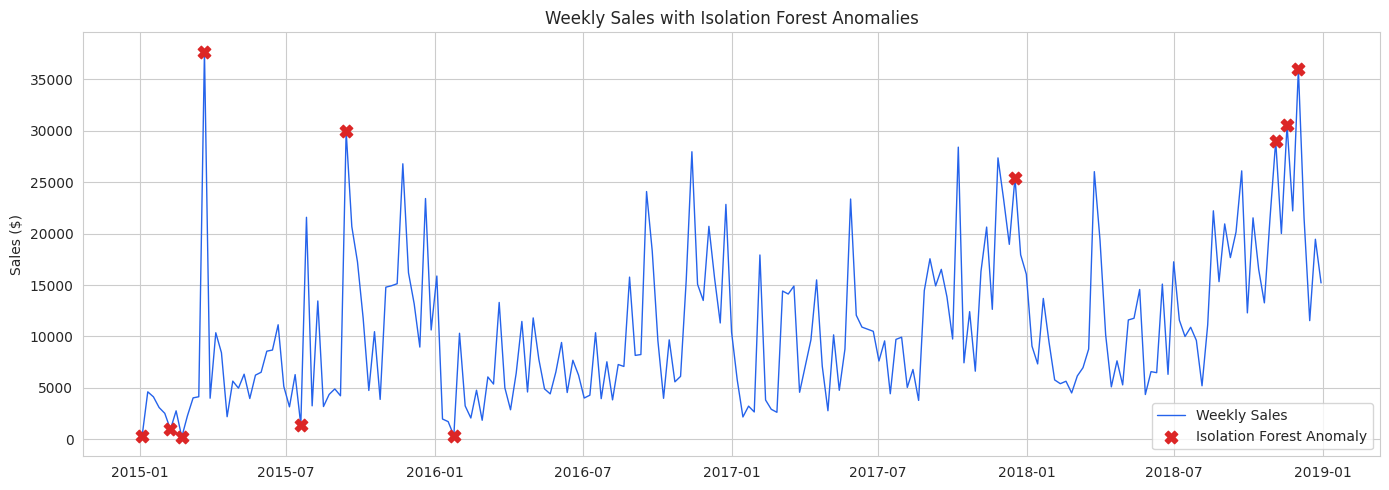

In [44]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(anomaly_df.index, anomaly_df['Sales'], color='#2563eb', linewidth=1, label='Weekly Sales', zorder=1)
ax.scatter(iso_anomalies.index, iso_anomalies['Sales'], color='#dc2626', s=80, zorder=3,
           marker='X', label='Isolation Forest Anomaly')
ax.set_title('Weekly Sales with Isolation Forest Anomalies')
ax.set_ylabel('Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/task5_isolation_forest_anomalies.png', dpi=120)
plt.show()

### Possible Real-World Explanations for Isolation Forest Anomalies

| Week | Sales | Likely Explanation |
|---|---|---|
| 2015-01-04 | ~$305 (very low) | First week of January — classic post-holiday spending lull, consistent with January being our weakest month overall (Task 1/2) |
| 2015-02-08, 2015-02-22 | ~$969 / $225 (very low) | February troughs — matches February being the single weakest month in our seasonality analysis |
| 2015-03-22 | ~$37,704 (spike) | Likely a large one-off bulk/B2B order — flagged by *both* methods (see below), so it's a genuine, strong outlier |
| 2015-07-19 | ~$1,388 (very low) | Mid-summer lull with no offsetting large orders that week |
| 2015-09-13 | ~$29,959 (spike) | Consistent with Task 2's finding that September carries unusually high *residual* noise — likely an irregular back-to-school bulk order layered on top of normal September seasonality |
| 2016-01-24 | ~$359 (very low) | Another January post-holiday lull |
| 2017-12-17 | ~$25,450 (spike) | Pre-Christmas holiday shopping surge — expected given December's strong seasonal boost |
| 2018-11-04, 2018-11-18 | ~$29,017 / $30,572 (spikes) | Black Friday run-up / November holiday shopping surge |
| 2018-12-02 | ~$35,999 (spike) | Cyber Monday / early-December holiday shopping surge |

Notice the pattern: **low-sales anomalies cluster in Jan/Feb/summer** (genuinely quiet periods), while **high-sales anomalies cluster around Sep, Nov, and Dec** (known seasonal peaks) — the anomaly detector is essentially re-discovering our known seasonality pattern at the extremes, plus flagging a few weeks (Mar 2015, Sep 2015) that go beyond what seasonality alone would predict.

In [45]:
window = 8
anomaly_df['roll_mean'] = anomaly_df['Sales'].rolling(window, min_periods=4, center=True).mean()
anomaly_df['roll_std']  = anomaly_df['Sales'].rolling(window, min_periods=4, center=True).std()
anomaly_df['zscore']    = (anomaly_df['Sales'] - anomaly_df['roll_mean']) / anomaly_df['roll_std']
anomaly_df['z_is_anomaly'] = anomaly_df['zscore'].abs() > 2

z_anomalies = anomaly_df[anomaly_df['z_is_anomaly']]
print(f"Z-score method flagged {len(z_anomalies)} anomalous weeks out of {len(anomaly_df)}:")
z_anomalies[['Sales', 'zscore']]

Z-score method flagged 6 anomalous weeks out of 209:


,Sales,zscore
Order Date,,
2015-03-22,37703.665,2.384855
2015-07-26,21590.080,2.088711
2016-03-20,13310.136,2.209014
2017-02-05,17926.368,2.419527
2017-05-28,23367.662,2.105511
2017-10-08,28412.098,2.128709


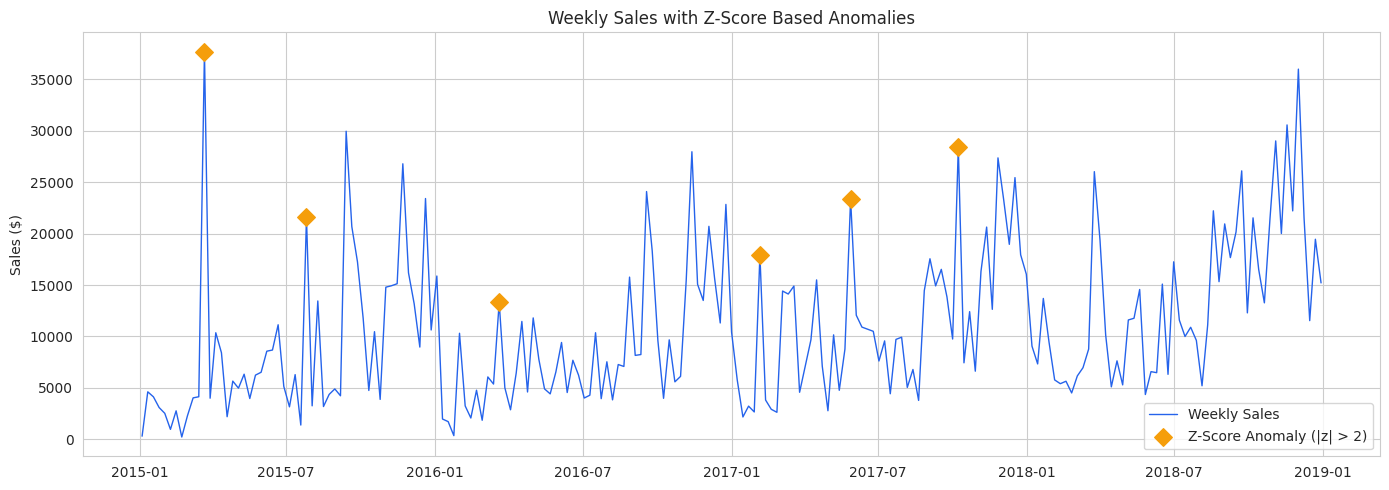

In [46]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(anomaly_df.index, anomaly_df['Sales'], color='#2563eb', linewidth=1, label='Weekly Sales', zorder=1)
ax.scatter(z_anomalies.index, z_anomalies['Sales'], color='#f59e0b', s=80, zorder=3,
           marker='D', label='Z-Score Anomaly (|z| > 2)')
ax.set_title('Weekly Sales with Z-Score Based Anomalies')
ax.set_ylabel('Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/task5_zscore_anomalies.png', dpi=120)
plt.show()

### Real-World Explanations for Z-Score Anomalies

All 6 Z-score anomalies are **positive spikes** (weeks that jumped well above their immediate neighboring weeks): **March 2015, July 2015, March 2016, February 2017, May 2017, and October 2017.** Each looks like a sudden, unscheduled bulk order or short-lived promotion that stands out *relative to the quiet weeks right around it* — even in months (like February or July) that aren't globally high-selling months. For example, the **February 2017** spike wouldn't be flagged by Isolation Forest as one of the most extreme weeks in the whole dataset, but locally it's a clear jump above its otherwise slow February neighbors.

In [47]:
iso_dates = set(iso_anomalies.index)
z_dates   = set(z_anomalies.index)
common    = iso_dates & z_dates
only_iso  = iso_dates - z_dates
only_z    = z_dates - iso_dates

print(f"Isolation Forest flagged: {len(iso_dates)} weeks")
print(f"Z-score flagged:          {len(z_dates)} weeks")
print(f"Flagged by BOTH methods:  {len(common)} week(s) -> {sorted(common)}")
print(f"Flagged ONLY by Isolation Forest: {len(only_iso)} weeks")
print(f"Flagged ONLY by Z-score:          {len(only_z)} weeks")

Isolation Forest flagged: 11 weeks
Z-score flagged:          6 weeks
Flagged by BOTH methods:  1 week(s) -> [Timestamp('2015-03-22 00:00:00')]
Flagged ONLY by Isolation Forest: 10 weeks
Flagged ONLY by Z-score:          5 weeks


**Do both methods agree?** Mostly **no** — they overlap on only **1 out of 16 total flagged weeks** (the March 22, 2015 spike, which both methods independently agree is a genuine outlier).

**What this tells us:**
- **Isolation Forest is a *global* detector** — it compares every week against the entire 4-year distribution, so it naturally flags the Jan/Feb *seasonal lows* and Nov/Dec *seasonal highs* as "anomalous," even though those are actually *expected, recurring* patterns rather than true one-off surprises. It's good at spotting "this is one of the most extreme weeks we've ever had," but conflates genuine surprises with predictable seasonal extremes.
- **Z-score (rolling-window) is a *local/relative* detector** — it only flags a week if it jumps out *relative to its immediate neighbors*, regardless of whether that week's absolute level is a global extreme. This is why it catches things like the February 2017 spike (unremarkable globally, but a clear local jump) while *not* flagging routine January/February lows (since neighboring weeks are similarly low, so there's no local deviation).
- **The one point of agreement (March 22, 2015)** is the strongest signal of a genuine one-off anomaly in this dataset — it's extreme both in absolute terms *and* relative to its neighbors.
- **Practical takeaway:** for a real business anomaly-alerting system, a hybrid approach makes sense — use the **Z-score/local method as the primary "surprise" detector** (since it won't cry wolf every holiday season), and use **Isolation Forest as a secondary check** to catch genuinely extreme global outliers that might still be worth a second look even if they're seasonally "expected."

In [48]:
subcategories = df['Sub-Category'].unique()

feature_rows = []
for sc in subcategories:
    sub = df[df['Sub-Category'] == sc]

    total_sales = sub['Sales'].sum()
    avg_order_value = sub.groupby('Order ID')['Sales'].sum().mean()

    monthly = sub.set_index('Order Date').resample('ME')['Sales'].sum()
    monthly = monthly.reindex(
        pd.date_range(df['Order Date'].min(), df['Order Date'].max(), freq='ME'), fill_value=0
    )
    volatility = monthly.std()

    yearly = sub.groupby(sub['Order Date'].dt.year)['Sales'].sum().reindex([2015, 2016, 2017, 2018], fill_value=0)
    yoy_growth = yearly.pct_change().dropna().mean() * 100

    feature_rows.append([sc, total_sales, yoy_growth, volatility, avg_order_value])

subcat_features = pd.DataFrame(
    feature_rows, columns=['Sub-Category', 'TotalSales', 'YoYGrowthPct', 'Volatility', 'AvgOrderValue']
)
subcat_features.round(1)

,Sub-Category,TotalSales,YoYGrowthPct,Volatility,AvgOrderValue
0,Bookcases,113813.2,23.8,2245.3,512.7
1,Chairs,322822.7,7.1,4282.3,570.4
2,Labels,12347.7,12.2,225.9,36.3
3,Tables,202810.6,16.4,3189.2,671.6
4,Storage,219343.4,13.2,2726.4,287.1
5,Furnishings,89212.0,28.8,1335.0,104.3
6,Art,26705.4,16.6,330.9,37.1
7,Phones,327782.4,12.3,4082.9,408.2
8,Binders,200028.8,21.9,3888.8,154.9
9,Appliances,104618.4,39.9,1725.4,235.6


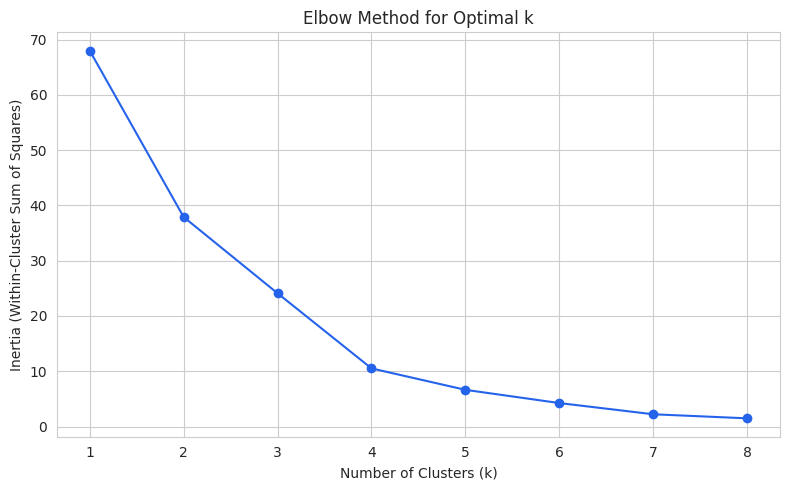

k=1: inertia=68.0
k=2: inertia=37.9
k=3: inertia=24.1
k=4: inertia=10.5
k=5: inertia=6.6
k=6: inertia=4.2
k=7: inertia=2.2
k=8: inertia=1.5


In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_feature_cols = ['TotalSales', 'YoYGrowthPct', 'Volatility', 'AvgOrderValue']
X_cluster = subcat_features[cluster_feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, marker='o', color='#2563eb')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_title('Elbow Method for Optimal k')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig('charts/task6_elbow_method.png', dpi=120)
plt.show()

for k, i in zip(k_range, inertias):
    print(f"k={k}: inertia={i:.1f}")

In [50]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
subcat_features['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = subcat_features.groupby('Cluster')[cluster_feature_cols].mean().round(1)
cluster_profile['# Sub-Categories'] = subcat_features['Cluster'].value_counts()
print("Cluster profiles (average feature values):")
print(cluster_profile)
print()
print("Sub-categories per cluster:")
for c in sorted(subcat_features['Cluster'].unique()):
    members = subcat_features[subcat_features['Cluster'] == c]['Sub-Category'].tolist()
    print(f"Cluster {c}: {members}")

Cluster profiles (average feature values):
         TotalSales  YoYGrowthPct  Volatility  AvgOrderValue  # Sub-Categories
Cluster                                                                       
0           55331.9          20.0       890.5          134.1                 8
1          167743.4          46.3      5213.7         1952.8                 2
2          239495.8          18.1      3461.2          387.7                 6
3           46420.3         192.8      1966.1          256.5                 1

Sub-categories per cluster:
Cluster 0: ['Bookcases', 'Labels', 'Furnishings', 'Art', 'Appliances', 'Paper', 'Envelopes', 'Fasteners']
Cluster 1: ['Machines', 'Copiers']
Cluster 2: ['Chairs', 'Tables', 'Storage', 'Phones', 'Binders', 'Accessories']
Cluster 3: ['Supplies']


In [51]:
cluster_labels = {
    0: 'Low Volume, Stable Demand',
    1: 'High-Value, High-Volatility (Big-Ticket) Growing Demand',
    2: 'High Volume, Stable Demand',
    3: 'Small Base, Rapid Growth (Emerging Demand)',
}
subcat_features['Cluster Label'] = subcat_features['Cluster'].map(cluster_labels)

subcat_features.sort_values(['Cluster', 'TotalSales'], ascending=[True, False])[
    ['Sub-Category', 'Cluster', 'Cluster Label', 'TotalSales', 'YoYGrowthPct', 'Volatility', 'AvgOrderValue']
]

,Sub-Category,Cluster,Cluster Label,TotalSales,YoYGrowthPct,Volatility,AvgOrderValue
0,Bookcases,0,"Low Volume, Stable Demand",113813.1987,23.806516,2245.338407,512.672066
9,Appliances,0,"Low Volume, Stable Demand",104618.4030,39.927584,1725.443346,235.627034
5,Furnishings,0,"Low Volume, Stable Demand",89212.0180,28.788938,1334.953477,104.341542
10,Paper,0,"Low Volume, Stable Demand",76828.3040,25.413074,978.089019,66.060451
6,Art,0,"Low Volume, Stable Demand",26705.4100,16.605553,330.936888,37.090847
12,Envelopes,0,"Low Volume, Stable Demand",16128.0460,-2.766643,236.506685,66.370560
2,Labels,0,"Low Volume, Stable Demand",12347.7260,12.192651,225.864536,36.316841
13,Fasteners,0,"Low Volume, Stable Demand",3001.9600,15.703383,46.969327,14.160189
15,Machines,1,"High-Value, High-Volatility (Big-Ticket) Growi...",189238.6310,8.006001,5433.298274,1689.630634
16,Copiers,1,"High-Value, High-Volatility (Big-Ticket) Growi...",146248.0940,84.671819,4994.194694,2215.880212


**How the clusters were labeled** (based on the actual cluster-average feature values above):
- **Cluster 0 — Low Volume, Stable Demand** (8 sub-categories: Bookcases, Labels, Art, Furnishings, Envelopes, Fasteners, Paper, Appliances): lowest average volatility (~$890) and modest total sales (~$55K avg) — small, steady, unremarkable sellers.
- **Cluster 1 — High-Value, High-Volatility, Growing Demand** (2: Machines, Copiers): by far the **highest average order value (~$1,953)** and highest volatility (~$5,214) — these are expensive, infrequently-purchased big-ticket items where a single large order swings the monthly total dramatically. Also the highest average growth (~46%) of any multi-item cluster.
- **Cluster 2 — High Volume, Stable Demand** (6: Chairs, Storage, Phones, Binders, Accessories, Tables): the **highest total sales** (~$239K avg) — these are the core, high-volume revenue drivers of the business, with moderate (not extreme) volatility and growth.
- **Cluster 3 — Small Base, Rapid Growth** (1: Supplies): an outlier cluster of one, driven by the extreme 193% YoY growth figure discussed above — worth watching but the growth number should be treated cautiously given its origin from a very small sales base.

In [52]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
subcat_features['PC1'] = principal_components[:, 0]
subcat_features['PC2'] = principal_components[:, 1]

print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"Total={sum(pca.explained_variance_ratio_):.1%}")

Explained variance ratio: PC1=57.5%, PC2=28.5%, Total=86.0%


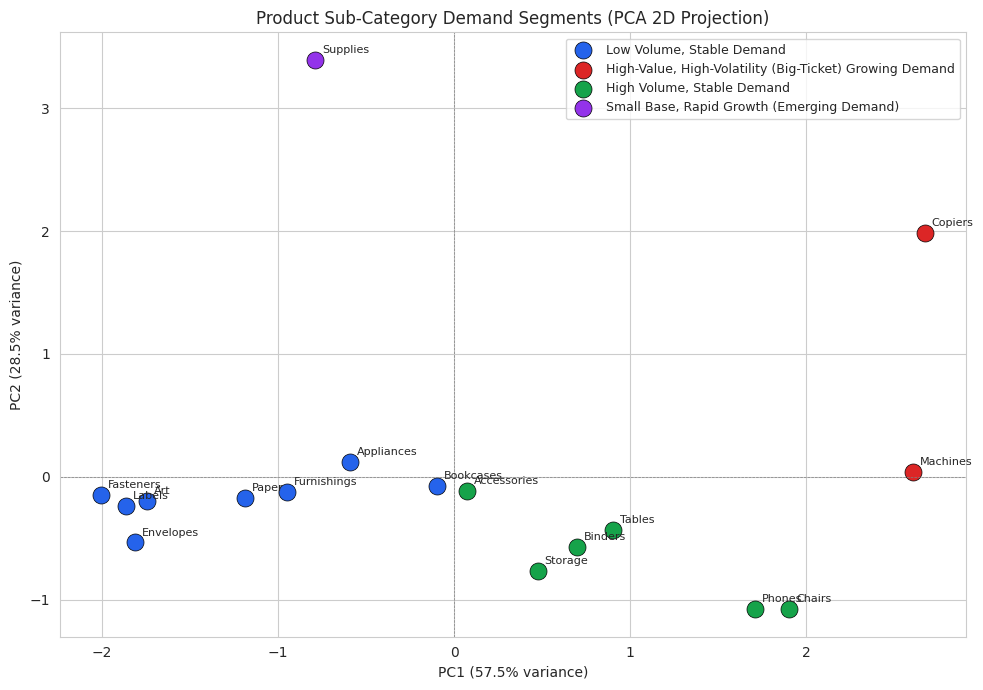

In [53]:
fig, ax = plt.subplots(figsize=(10, 7))
colors_map = {0: '#2563eb', 1: '#dc2626', 2: '#16a34a', 3: '#9333ea'}

for c in sorted(subcat_features['Cluster'].unique()):
    cluster_data = subcat_features[subcat_features['Cluster'] == c]
    ax.scatter(cluster_data['PC1'], cluster_data['PC2'], s=150, color=colors_map[c],
               label=cluster_labels[c], edgecolor='black', linewidth=0.5)

for _, row in subcat_features.iterrows():
    ax.annotate(row['Sub-Category'], (row['PC1'], row['PC2']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Product Sub-Category Demand Segments (PCA 2D Projection)')
ax.legend(loc='best', fontsize=9)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig('charts/task6_cluster_pca.png', dpi=120)
plt.show()

## Recommended Stocking Strategy per Cluster

| Cluster | Label | Stocking Strategy |
|---|---|---|
| **2** | High Volume, Stable Demand (Chairs, Storage, Phones, Binders, Accessories, Tables) | These are the business's bread-and-butter sellers. Maintain **higher safety stock and standard replenishment cycles** (e.g., automated reorder points). Negotiate volume discounts with suppliers given the predictable, steady demand — the low risk of dead stock justifies holding more inventory. |
| **1** | High-Value, High-Volatility, Growing Demand (Machines, Copiers) | Big-ticket items with lumpy, unpredictable order timing. Avoid holding large quantities of finished stock (high holding cost per unit); instead favor **just-in-time ordering, pre-order/backorder models, or a small buffer of 1-2 units** with a fast-reorder supplier relationship. Because this cluster is genuinely growing, plan for gradually increasing buffer stock, but monitor closely given the high volatility. |
| **0** | Low Volume, Stable Demand (Bookcases, Labels, Art, Furnishings, Envelopes, Fasteners, Paper, Appliances) | Low-risk, low-reward items. Keep **minimal on-hand stock** with a simple reorder-point system; avoid tying up capital and warehouse space in slow-moving inventory. |
| **3** | Small Base, Rapid Growth (Supplies) | Treat as a **watch-list item** — the extreme growth rate is real but originates from a small base, so it needs another 1-2 quarters of data before committing to a large stock increase. Recommend a **moderate, incremental stock increase** now with close month-to-month monitoring, rather than a large upfront investment based on a single volatile growth number. |